# **수정 사항**
- Threshold 산출 코드 수정

# **1. 드라이브 연결**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **2. 전처리 및 데이터셋 설정**

- 실험 별로 나누어서 진행

In [2]:
# ==========================================
# 1. 라이브러리 및 환경 설정
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import os
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. 통합 데이터 전처리 (Unified Dataset with Detailed Logs)
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"
if os.path.exists(file_path):
    print(f"\nLoading data from: {file_path}")
    df = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    df = pd.DataFrame()

sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):
    # 1. 데이터 추출
    data_values = df_target[sensor_cols].values

    # 2. 스케일링 (Train 만 Scale)
    if is_train:
        if scaler is None: scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        if scaler is None:
            raise ValueError("Test mode requires a fitted scaler from training data.")
        data_scaled = scaler.transform(data_values)

    # 스케일링된 데이터를 다시 df로 매핑
    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences, all_wafer_ids = [], []
    for wafer in df_scaled[wafer_col].unique():
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values
        if len(wafer_data) < seq_len: continue
        step_size = 1 # 필요 시 5나 10으로 늘려 메모리 관리
        for i in range(0, len(wafer_data) - seq_len + 1, step_size):
          all_sequences.append(wafer_data[i : i + seq_len])
          all_wafer_ids.append(wafer)

    if len(all_sequences) == 0: return np.array([]), np.array([]), scaler
    return np.array(all_sequences), np.array(all_wafer_ids), scaler

# ==========================================
# 2. 통합 데이터 전처리 (개선된 독립 스케일링 방식)
# ==========================================
experiments = ['l29', 'l31', 'l33']
datasets = {}
SEQ_LEN = 32
TRAIN_RATIO = 0.7

print(f"\n--- Preprocessing Data with Per-Experiment Scaling (Train Ratio: {TRAIN_RATIO*100}%) ---")

# 통합 데이터셋 구성을 위한 리스트
all_X_train, all_ids_train = [], []
all_X_test_norm, all_ids_test_norm = [], []
all_X_test_fault, all_ids_test_fault = [], []

for exp_id in experiments:
    print(f"\nProcessing Experiment: {exp_id}")

    exp_df = df[df['Wafer_ID'].str.contains(exp_id, case=False, na=False)]
    if exp_df.empty:
        continue

    # 1. Train / Test Split (Wafer ID 기준)
    normal_wafer_ids = exp_df[exp_df['Label'] == 'Normal']['Wafer_ID'].unique()
    fault_wafer_ids = exp_df[exp_df['Label'] == 'Fault']['Wafer_ID'].unique()

    n_train = int(len(normal_wafer_ids) * TRAIN_RATIO)
    train_ids = normal_wafer_ids[:n_train]
    test_norm_ids = normal_wafer_ids[n_train:]

    print(f"  - Total Normal: {len(normal_wafer_ids)}")
    print(f"  -> Train Normal : {len(train_ids)}")
    print(f"  -> Test Normal  : {len(test_norm_ids)}")
    print(f"  -> Test Fault   : {len(fault_wafer_ids)}")

    # DataFrame 분할
    exp_df_train = exp_df[exp_df['Wafer_ID'].isin(train_ids)]
    exp_df_test_norm = exp_df[exp_df['Wafer_ID'].isin(test_norm_ids)]
    exp_df_test_fault = exp_df[exp_df['Wafer_ID'].isin(fault_wafer_ids)]

    # 💡 2. 실험군별 독립적인 Scaler 적용 (핵심 변경 사항)
    # Train 데이터로만 Scaler 학습
    X_train_exp, ids_train_exp, exp_scaler = create_sequences_with_ids(
        exp_df_train, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True
    )

    # Test 데이터는 학습된 Scaler로 Transform만 수행
    X_test_norm_exp, ids_test_norm_exp, _ = create_sequences_with_ids(
        exp_df_test_norm, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=exp_scaler, is_train=False
    )

    if not exp_df_test_fault.empty:
        X_test_fault_exp, ids_test_fault_exp, _ = create_sequences_with_ids(
            exp_df_test_fault, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=exp_scaler, is_train=False
        )
    else:
        X_test_fault_exp, ids_test_fault_exp = np.array([]), np.array([])

    # 3. 스케일링이 완료된 데이터를 글로벌 리스트에 누적
    if len(X_train_exp) > 0:
        all_X_train.append(X_train_exp)
        all_ids_train.extend(ids_train_exp)
    if len(X_test_norm_exp) > 0:
        all_X_test_norm.append(X_test_norm_exp)
        all_ids_test_norm.extend(ids_test_norm_exp)
    if len(X_test_fault_exp) > 0:
        all_X_test_fault.append(X_test_fault_exp)
        all_ids_test_fault.extend(ids_test_fault_exp)

# 4. 루프 종료 후 최종 병합 (Unified Dataset)
datasets['Unified'] = {
    'X_train': np.vstack(all_X_train) if all_X_train else np.array([]),
    'ids_train': np.array(all_ids_train),
    'X_test_norm': np.vstack(all_X_test_norm) if all_X_test_norm else np.array([]),
    'ids_test_norm': np.array(all_ids_test_norm),
    'X_test_fault': np.vstack(all_X_test_fault) if all_X_test_fault else np.array([]),
    'ids_test_fault': np.array(all_ids_test_fault),
    'scaler': 'Per-Experiment Scalers Used' # 통합 스케일러 대신 개별 스케일러가 사용되었음을 명시
}

print("\n✅ Data preprocessing with Per-Experiment Scaling completed.")

Using device: cuda

Loading data from: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx

--- Preprocessing Data with Per-Experiment Scaling (Train Ratio: 70.0%) ---

Processing Experiment: l29
  - Total Normal: 34
  -> Train Normal : 23
  -> Test Normal  : 11
  -> Test Fault   : 9

Processing Experiment: l31
  - Total Normal: 37
  -> Train Normal : 25
  -> Test Normal  : 12
  -> Test Fault   : 6

Processing Experiment: l33
  - Total Normal: 37
  -> Train Normal : 25
  -> Test Normal  : 12
  -> Test Fault   : 6

✅ Data preprocessing with Per-Experiment Scaling completed.


# **3. 공통 함수 정의**

In [3]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame으로 매핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    # sort=False를 추가하여 순서가 섞이는 것을 방지합니다.
    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID', sort=False)['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID', sort=False)['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    preds = (scores > threshold).astype(int)
    f1 = f1_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    visualize_results(model_name, exp_id, scores, labels, threshold)
    return roc_auc, f1

# **4. 모델 구현 및 학습**

In [4]:
# ==========================================
# 실험별 모델 학습 및 비지도 임계값 산출
# ==========================================
if 'trained_artifacts' not in globals():
    trained_artifacts = {}

# 1. 공통 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
SIGMA_MULTIPLIER = 6

## **1D-CNN AE**

In [5]:
import torch
import torch.nn as nn

class CNN1D_AE(nn.Module):
    def __init__(self, num_sensors=19, seq_len=32, latent_dim=8):
        super(CNN1D_AE, self).__init__()

        # 논문 권장사항: 작은 Kernel Size 선호
        # 모델 경량화 및 seq_len=32를 고려하여 kernel_size=3, stride=2 사용

        # ---------------------------
        # Encoder (차원 축소)
        # ---------------------------
        self.encoder = nn.Sequential(
            # Input: (Batch, 19, 32) -> Output: (Batch, 32, 16)
            nn.Conv1d(in_channels=num_sensors, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # 각 레이어마다 ReLU 적용

            # Input: (Batch, 32, 16) -> Output: (Batch, 16, 8)
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Input: (Batch, 16, 8) -> Output: (Batch, latent_dim, 4)
            nn.Conv1d(in_channels=16, out_channels=latent_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # ---------------------------
        # Decoder (대칭적 복원 )
        # ---------------------------
        self.decoder = nn.Sequential(
            # Input: (Batch, latent_dim, 4) -> Output: (Batch, 16, 8)
            nn.ConvTranspose1d(in_channels=latent_dim, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Input: (Batch, 16, 8) -> Output: (Batch, 32, 16)
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Input: (Batch, 32, 16) -> Output: (Batch, 19, 32)
            # 마지막 레이어는 입력 데이터의 스케일(MinMax, 0~1)에 맞춰 Sigmoid를 적용하거나 생략할 수 있습니다.
            nn.ConvTranspose1d(in_channels=32, out_channels=num_sensors, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 🚨 중요: 이전 단계에서 언급했던 차원 변환 (Batch, Seq_Len, Sensors) -> (Batch, Sensors, Seq_Len)
        x = x.transpose(1, 2)

        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        # 출력 시 다시 원래 형태로 복구 (Batch, Seq_Len, Sensors)
        return reconstructed.transpose(1, 2)



import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def train_cnn1d(model, train_loader, optimizer, epoch, device):
    model.train()
    total_loss = 0
    criterion = nn.L1Loss() # MAE Loss

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # AE는 자기 자신을 타겟으로 복원
        output = model(data)
        loss = criterion(output, data)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 에포크가 많으므로 10단위 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def cnn1d_calculate_window_scores(model, data_tensor, device, batch_size=32):
    model.eval()
    all_scores = []
    criterion = nn.L1Loss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            output = model(data)

            # Element-wise MAE Loss: (Batch, Seq_Len, Num_Sensors)
            loss_element = criterion(output, data)

            # [논문 반영] Localised Reconstruction Error (LRE)
            # 1. 채널별(byChannel) 시간축 평균 에러 계산 -> (Batch, Num_Sensors)
            channel_errors = loss_element.mean(dim=1)
            # 2. 센서 중 가장 높은 오차값을 윈도우 스코어로 사용 -> (Batch)
            score_window, _ = channel_errors.max(dim=1)

            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

In [6]:
# ==========================================
# [Cell 2] 학습 및 임계값 설정 (Training Phase)
# ==========================================
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 설정 및 고유 변수
EXP_ID = 'Unified'
m_name = "1D-CNN AE"

BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
PERCENTILE_THRESHOLD = 99  # 임계값 결정을 위한 상위 백분위수

cnn_config = {
    "latent_dim": 16
}

if 'trained_artifacts' not in globals():
    trained_artifacts = {}
if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on {EXP_ID} Dataset")

if EXP_ID not in datasets:
    raise ValueError(f"Dataset '{EXP_ID}' not found. Please run the preprocessing cell first.")

# 2. 데이터 로드 (Train 만 수행)
train_loader, _, _ = get_data_loaders(EXP_ID, datasets, BATCH_SIZE)
num_sensors = train_loader.dataset.tensors[0].shape[2]
seq_len_input = train_loader.dataset.tensors[0].shape[1]

# 3. 모델 초기화
model = CNN1D_AE(
    num_sensors=num_sensors,
    seq_len=seq_len_input,
    latent_dim=cnn_config["latent_dim"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 4. 학습 시작
print("Training started...")
for epoch in range(NUM_EPOCHS):
    train_cnn1d(model, train_loader, optimizer, epoch, device)

# 5. 비지도 학습 임계값 계산 (Train Score 기준)
print(f"\n Calculating Train Scores for {m_name} Thresholding...")
train_tensor = train_loader.dataset.tensors[0]
train_window_scores = cnn1d_calculate_window_scores(model, train_tensor, device, BATCH_SIZE)

ids_train = datasets[EXP_ID]['ids_train']
_, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

train_mean = np.mean(train_wafer_scores)
train_std = np.std(train_wafer_scores)
fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

# 6. 전역 딕셔너리에 저장 (추론 시 재사용)
trained_artifacts[m_name][EXP_ID] = {
    'model': model,
    'threshold': fixed_threshold,
    'config': cnn_config
}
print(f"✅ [{m_name}] successfully trained and saved to artifacts.")


🚀 Phase 1: Training [1D-CNN AE] on Unified Dataset

📊 [Data Setup] Experiment: Unified
Training started...
Epoch [10] Loss: 0.0872
Epoch [20] Loss: 0.0837
Epoch [30] Loss: 0.0818
Epoch [40] Loss: 0.0807
Epoch [50] Loss: 0.0796

 Calculating Train Scores for 1D-CNN AE Thresholding...
   * Train Score Mean: 0.2765, Std: 0.0527
   * Fixed 6-Sigma Threshold: 0.5925
✅ [1D-CNN AE] successfully trained and saved to artifacts.


## **LSTM-AE**

## **LOF-IF**

## **TranAD**

## **VTimesNet**

In [7]:
import torch
import torch.nn as nn
import torch.fft
import torch.nn.functional as F

class DCM(nn.Module):
    """
    Dilated Convolutional Module (2D 기반 다중 스케일 특징 추출)
    논문: 팽창률(Dilation rate) 2, 커널 크기 {1,2,3,4,5,6} 병렬 적용 [cite: 127]
    """
    def __init__(self, in_channels):
        super(DCM, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, in_channels, kernel_size=k, padding='same', dilation=2)
            for k in range(1, 7)
        ])

    def forward(self, x):
        # 다중 스케일 특징 F1 ~ F6 반환
        return [conv(x) for conv in self.convs]

class GLGM(nn.Module):
    """
    Global-Local-Global Fusion Module
    논문: Global-Local 경로와 Local-Global 경로를 통한 양방향 정보 융합 [cite: 170, 174, 179]
    """
    def __init__(self, channels):
        super(GLGM, self).__init__()
        # 논문 구조상 단순화를 위해 1x1 Conv로 스케일 융합을 모사 (실제 구현 시 해상도 조절 가능)
        self.fusion_conv = nn.Conv2d(channels * 6, channels, kernel_size=3, padding=1)

    def forward(self, features):
        # 6개의 다중 스케일 특징(F1~F6)을 양방향 융합 (단순화된 병합 구조)
        concat_features = torch.cat(features, dim=1)
        out = self.fusion_conv(concat_features)
        return out

class CBAM(nn.Module):
    """
    Convolutional Block Attention Module
    논문: 채널 어텐션과 공간 어텐션을 순차적으로 적용 [cite: 184, 185, 190]
    """
    def __init__(self, channels):
        super(CBAM, self).__init__()
        # Channel Attention [cite: 186, 187, 188]
        self.ca_mlp = nn.Sequential(
            nn.Conv2d(channels, channels // 2, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels, 1, bias=False)
        )
        self.ca_sigmoid = nn.Sigmoid()

        # Spatial Attention [cite: 191, 192]
        self.sa_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sa_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. Channel Attention
        avg_out = self.ca_mlp(F.adaptive_avg_pool2d(x, 1))
        max_out = self.ca_mlp(F.adaptive_max_pool2d(x, 1))
        ca_weight = self.ca_sigmoid(avg_out + max_out)
        x = x * ca_weight

        # 2. Spatial Attention
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        sa_weight = self.sa_sigmoid(self.sa_conv(torch.cat([avg_pool, max_pool], dim=1)))
        x = x * sa_weight
        return x

class TimesPlusBlock(nn.Module):
    """
    V-TimesNet의 핵심 블록: 1D -> 2D 변환 -> 비전 모듈(DCM, GLGM, CBAM) -> 1D 복원 [cite: 96, 116, 119]
    """
    def __init__(self, d_model, k=3):
        super(TimesPlusBlock, self).__init__()
        self.k = k
        self.dcm = DCM(d_model)
        self.glgm = GLGM(d_model)
        self.cbam = CBAM(d_model)

    def forward(self, x):
        B, C, T = x.size()
        x_fft = torch.fft.rfft(x, dim=-1)
        ampls = torch.abs(x_fft)

        avg_ampls = ampls.mean(dim=0).mean(dim=0)
        topk_ampls, topk_indices = torch.topk(avg_ampls, k=self.k)

        res = []
        for idx in topk_indices:
            freq = idx.item()
            period = 1 if freq == 0 else T // freq

            pad_len = 0 if T % period == 0 else period - (T % period)
            x_pad = F.pad(x, (0, pad_len)) if pad_len > 0 else x

            # 1. 1D to 2D Reshape [cite: 84]
            x_2d = x_pad.view(B, C, -1, period)

            # 2. Vision Modules (DCM -> GLGM -> CBAM) [cite: 96]
            dcm_out = self.dcm(x_2d)
            glgm_out = self.glgm(dcm_out)
            out_2d = self.cbam(glgm_out)

            # 3. 2D to 1D Reshape [cite: 96]
            out_1d = out_2d.view(B, C, -1)
            if pad_len > 0:
                out_1d = out_1d[..., :-pad_len]
            res.append(out_1d)

        res = torch.stack(res, dim=-1)
        weights = torch.softmax(topk_ampls, dim=-1).unsqueeze(0).unsqueeze(0).unsqueeze(0)
        out = torch.sum(res * weights.to(x.device), dim=-1)

        return out + x # Residual Connection [cite: 79]

class VTimesNet(nn.Module):
    def __init__(self, seq_len, n_features, d_model=4, k=3, num_layers=3, fcn_dim=16):
        super(VTimesNet, self).__init__()
        self.embedding = nn.Linear(n_features, d_model)

        # P개의 TimesPlus 블록 적층 (논문 기준 3개) [cite: 73, 266]
        self.layers = nn.ModuleList([TimesPlusBlock(d_model, k=k) for _ in range(num_layers)])

        # Reconstruction Head: FCN dimension 반영 [cite: 379, 380]
        self.projection = nn.Sequential(
            nn.Linear(d_model, fcn_dim),
            nn.GELU(),
            nn.Linear(fcn_dim, n_features)
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) # [B, d_model, T]
        for layer in self.layers:
            x = layer(x)
        x = x.permute(0, 2, 1) # [B, T, d_model]
        x = self.projection(x)
        return x


import time
import torch.optim as optim

def train_vtimesnet(model, train_loader, optimizer, device):
    """1 Epoch 동안 V-TimesNet을 학습하는 함수"""
    model.train()
    total_loss = 0
    criterion = nn.MSELoss()

    for batch in train_loader:
        x_batch = batch[0].to(device)

        optimizer.zero_grad()
        output = model(x_batch)

        # 재구성 손실 (Reconstruction Loss) 계산
        loss = criterion(output, x_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def vtimesnet_calculate_window_scores(model, tensor_data, device, batch_size=32):
    """
    배치 단위로 V-TimesNet 추론을 진행하여 Window-level Anomaly Score(MSE) 계산
    (OOM 방지를 위해 DataLoader 사용)
    """
    model.eval()
    scores = []
    dataset = TensorDataset(tensor_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            x_batch = batch[0].to(device)
            reconstruction = model(x_batch)

            # Sample 단위 MSE 계산: (Batch, Seq_len, Features) -> (Batch)
            loss = torch.mean((x_batch - reconstruction) ** 2, dim=[1, 2])
            scores.extend(loss.cpu().numpy())

    return np.array(scores)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if 'trained_artifacts' not in globals():
    trained_artifacts = {}

# 1. 설정 및 고유 변수
EXP_ID = 'Unified'
m_name = "V-TimesNet"

BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
PERCENTILE_THRESHOLD = 99  # 임계값 설정을 위한 Percentile (이전 코드 기준)

vtimesnet_config = {
    "d_model": 64,
    "k": 3  # V-TimesNet 전용 하이퍼파라미터
}

if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on {EXP_ID} Dataset")

if EXP_ID not in datasets:
    raise ValueError(f"Dataset '{EXP_ID}' not found. Please run the preprocessing cell first.")

# 2. 데이터 로드 (Train 만 수행)
train_loader, _, _ = get_data_loaders(EXP_ID, datasets, BATCH_SIZE)
num_sensors = train_loader.dataset.tensors[0].shape[2]
seq_len_input = train_loader.dataset.tensors[0].shape[1]

# 3. 모델 초기화 (V-TimesNet은 입력 시퀀스 길이 그대로 사용)
model = VTimesNet(
    seq_len=seq_len_input,
    n_features=num_sensors,
    d_model=vtimesnet_config["d_model"],
    k=vtimesnet_config["k"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 4. 학습 시작
print("Training started...")
for epoch in range(NUM_EPOCHS):
    # V-TimesNet 전용 학습 함수 호출
    avg_loss = train_vtimesnet(model, train_loader, optimizer, device)
    if (epoch + 1) % 10 == 0:
        print(f"  - Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.6f}")

# 5. 비지도 학습 임계값 계산 (Train Score 기준)
print(f"\nCalculating Train Scores for {m_name} Thresholding...")
train_tensor = train_loader.dataset.tensors[0]

# V-TimesNet 전용 스코어(MSE) 계산 함수 호출
train_window_scores = vtimesnet_calculate_window_scores(model, train_tensor, device, BATCH_SIZE)

ids_train = datasets[EXP_ID]['ids_train']
_, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

train_mean = np.mean(train_wafer_scores)
train_std = np.std(train_wafer_scores)
fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

# 6. 전역 딕셔너리에 저장 (추론 시 재사용)
trained_artifacts[m_name][EXP_ID] = {
    'model': model,
    'threshold': fixed_threshold,
    'config': vtimesnet_config
}
print(f"✅ [{m_name}] successfully trained and saved to artifacts.")


🚀 Phase 1: Training [V-TimesNet] on Unified Dataset

📊 [Data Setup] Experiment: Unified
Training started...
  - Epoch [10/50], Loss: 0.002272
  - Epoch [20/50], Loss: 0.001270
  - Epoch [30/50], Loss: 0.000921
  - Epoch [40/50], Loss: 0.000822
  - Epoch [50/50], Loss: 0.000780

Calculating Train Scores for V-TimesNet Thresholding...
   * Train Score Mean: 0.0017, Std: 0.0002
   * Fixed 6-Sigma Threshold: 0.0031
✅ [V-TimesNet] successfully trained and saved to artifacts.


## **TRACE-GPT**

In [9]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=64, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        tcn_channels = [d_model] * 4
        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1,
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        # ✅ Data Leakage 방지를 위한 TransformerEncoder 사용
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)
        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)
        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits

# 3. Helper 함수
def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx

def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)
        loss = criterion(output_logits.reshape(-1, resolution), target_idx.reshape(-1))

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ✅ 10 에폭 단위로 출력하도록 수정됨
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:2d}] Loss: {avg_loss:.4f}")
    return avg_loss

def trace_calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')
    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]
            target_seq = data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)

            output_logits = model(input_seq)
            loss_element = criterion(output_logits.reshape(-1, resolution), target_idx.reshape(-1))
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

In [10]:
# ==========================================
# [Cell 2] 학습 및 임계값 설정 (Training Phase)
# ==========================================
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 설정 및 고유 변수
EXP_ID = 'Unified'
m_name = "TRACE-GPT"

BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001

trace_config = {
    "d_model": 64,
    "resolution": 100
}

if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on {EXP_ID} Dataset")

if EXP_ID not in datasets:
    raise ValueError(f"Dataset '{EXP_ID}' not found. Please run the preprocessing cell first.")

# 2. 데이터 로드 (Train 만 수행)
train_loader, _, _ = get_data_loaders(EXP_ID, datasets, BATCH_SIZE)
num_sensors = train_loader.dataset.tensors[0].shape[2]
seq_len_input = train_loader.dataset.tensors[0].shape[1]

# 3. 모델 초기화
model = TRACE_GPT(
    num_sensors=num_sensors,
    seq_len=seq_len_input - 1,
    d_model=trace_config["d_model"],
    resolution=trace_config["resolution"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 4. 학습 시작
print("Training started...")
for epoch in range(NUM_EPOCHS):
    train_trace_gpt(model, train_loader, optimizer, epoch, device, trace_config["resolution"])

# 5. 비지도 학습 임계값 계산 (Train Score 기준)
print(f"\n Calculating Train Scores for {m_name} Thresholding...")
train_tensor = train_loader.dataset.tensors[0]
train_window_scores = trace_calculate_window_scores(model, train_tensor, device, BATCH_SIZE, trace_config["resolution"])

ids_train = datasets[EXP_ID]['ids_train']
_, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

train_mean = np.mean(train_wafer_scores)
train_std = np.std(train_wafer_scores)
fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

# 6. 전역 딕셔너리에 저장 (추론 시 재사용)
trained_artifacts[m_name][EXP_ID] = {
    'model': model,
    'threshold': fixed_threshold,
    'config': trace_config
}
print(f"✅ [{m_name}] successfully trained and saved to artifacts.")


🚀 Phase 1: Training [TRACE-GPT] on Unified Dataset

📊 [Data Setup] Experiment: Unified
Training started...
Epoch [10] Loss: 2.2003
Epoch [20] Loss: 2.0936
Epoch [30] Loss: 2.0312
Epoch [40] Loss: 1.9721
Epoch [50] Loss: 1.9193

 Calculating Train Scores for TRACE-GPT Thresholding...
   * Train Score Mean: 2.1758, Std: 0.0558
   * Fixed 6-Sigma Threshold: 2.5106
✅ [TRACE-GPT] successfully trained and saved to artifacts.


# **5. 모델 성능 결과**

## **1D-CNN AE**


🔍 Phase 2: Evaluating [1D-CNN AE] on Unified Dataset
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.291235

📌 [1D-CNN AE - Unified] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.8245
   - F1-Score       : 0.6531 (at Fixed Threshold: 0.291235)


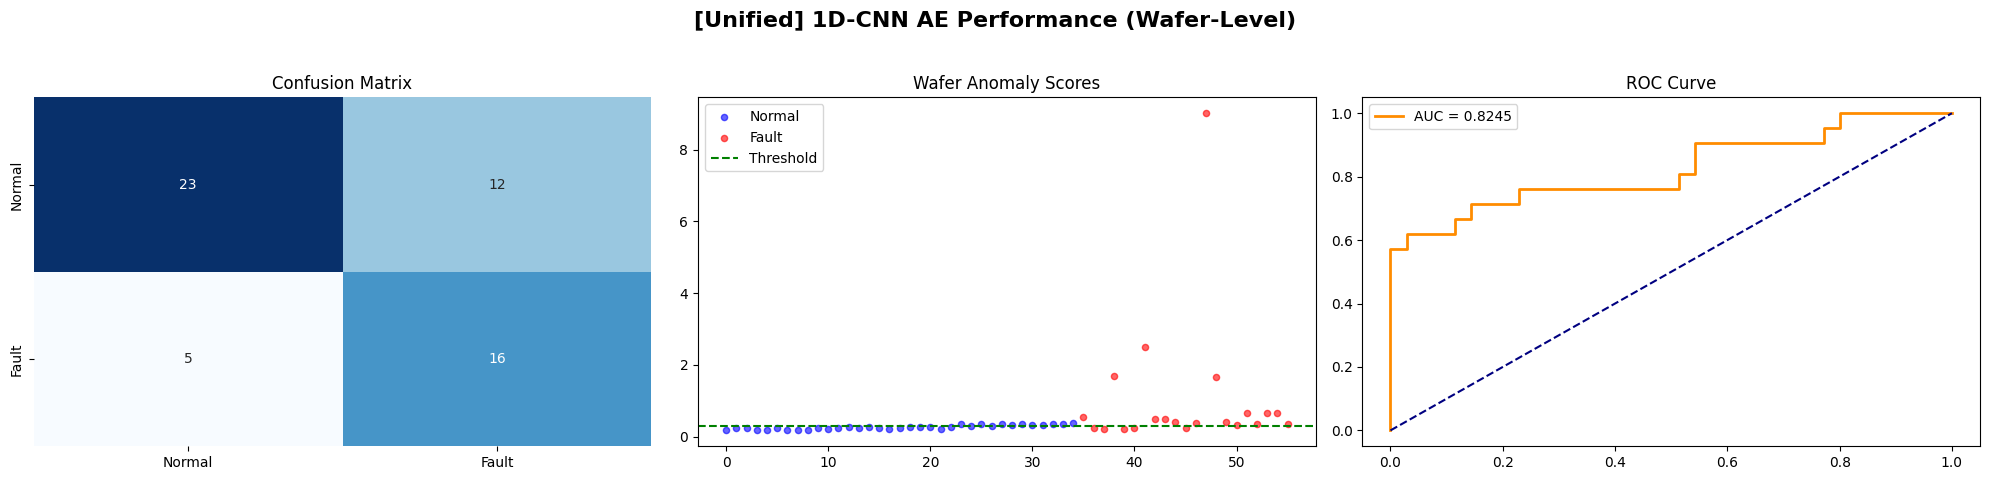

✅ Evaluation metrics for [1D-CNN AE] saved.


In [11]:
# ==========================================
# [Cell 3] 추론 및 평가 (Evaluation Phase)
# ==========================================
EXP_ID = 'Unified'
m_name = "1D-CNN AE"
BATCH_SIZE = 32

if m_name not in trained_artifacts or EXP_ID not in trained_artifacts[m_name]:
    print(f"❌ Error: Model '{m_name}' is not trained on '{EXP_ID}' yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on {EXP_ID} Dataset")

    # 1. 저장된 모델과 고유 변수 불러오기
    saved_model = trained_artifacts[m_name][EXP_ID]['model']
    fixed_threshold = trained_artifacts[m_name][EXP_ID]['threshold']
    config = trained_artifacts[m_name][EXP_ID]['config']

    # 2. Test Data 준비
    data = datasets[EXP_ID]
    test_norm = torch.FloatTensor(data['X_test_norm']).to(device)

    if len(data['X_test_fault']) > 0:
        test_fault = torch.FloatTensor(data['X_test_fault']).to(device)
    else:
        test_fault = torch.FloatTensor([]).to(device)

    ids_norm = data['ids_test_norm']
    ids_fault = data['ids_test_fault']

    # 3. 추론 수행 (Test Data 전용)
    print("Calculating Test Window Scores...")
    norm_window_scores = cnn1d_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE)

    if len(test_fault) > 0:
        fault_window_scores = cnn1d_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE)
    else:
        fault_window_scores = np.array([])

    # 4. Wafer 단위 집계
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    CALIBRATION_WINDOW = 10

    if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
        calibration_scores = norm_wafer_scores[:CALIBRATION_WINDOW]
        cal_mean = np.mean(calibration_scores)
        cal_std = np.std(calibration_scores)
        # 보정된 Test 데이터의 평균과 편차를 바탕으로 3-Sigma 적용
        calibrated_threshold = cal_mean + (3 * cal_std)
        print(f"\n📏 Calibrated Threshold (from first {CALIBRATION_WINDOW} Test Wafers): {calibrated_threshold:.6f}")
    else:
        calibrated_threshold = fixed_threshold # 데이터가 부족하면 기존 Train 임계값 사용
        print("\n⚠️ Not enough data for calibration. Using Train-based threshold.")
    # ==========================================

    # 5. 평가 및 시각화 (기존 fixed_threshold 대신 calibrated_threshold 사용)
    if len(np.unique(final_labels)) > 1:
        auc_score, f1 = evaluate_performance_fixed_threshold(
            m_name, EXP_ID, final_scores, final_labels, calibrated_threshold
        )

    # 결과 저장용 딕셔너리 업데이트
    if 'results' not in globals():
        results = {}
    if m_name not in results:
        results[m_name] = {}

    results[m_name][EXP_ID] = {'AUC': auc_score, 'F1': f1}
    print(f"✅ Evaluation metrics for [{m_name}] saved.")

## **VTimesNet**


🔍 Phase 2: Evaluating [V-TimesNet] on Unified Dataset
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.001991

📌 [V-TimesNet - Unified] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.8082
   - F1-Score       : 0.7234 (at Fixed Threshold: 0.001991)


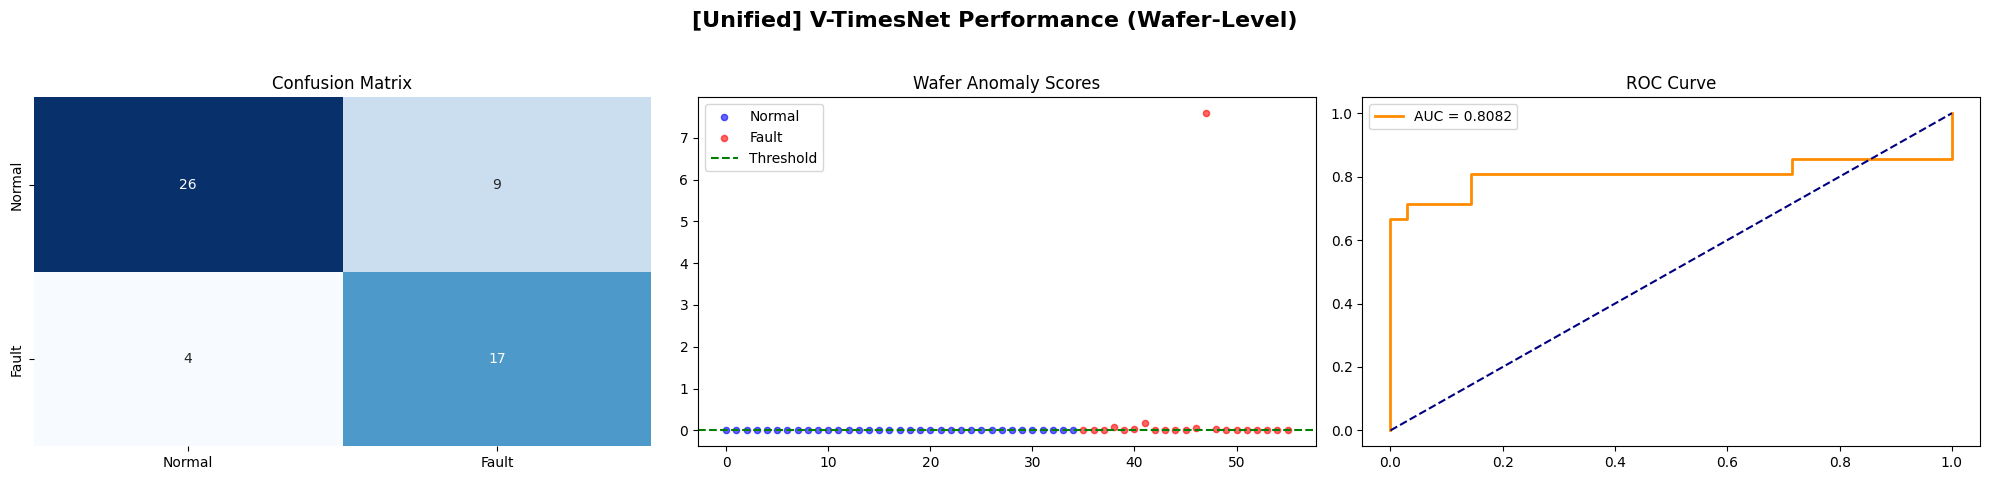

In [12]:
# ==========================================
# [Cell 3] 추론 및 평가 (Evaluation Phase)
# ==========================================
import torch
import numpy as np

EXP_ID = 'Unified'
m_name = "V-TimesNet"
BATCH_SIZE = 32

if m_name not in trained_artifacts or EXP_ID not in trained_artifacts[m_name]:
    print(f"❌ Error: Model '{m_name}' is not trained on '{EXP_ID}' yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on {EXP_ID} Dataset")

    # 1. 저장된 모델과 고유 변수 불러오기
    saved_model = trained_artifacts[m_name][EXP_ID]['model']
    fixed_threshold = trained_artifacts[m_name][EXP_ID]['threshold']
    config = trained_artifacts[m_name][EXP_ID]['config']

    # 2. Test Data 준비 (CPU 유지로 OOM 방지)
    data = datasets[EXP_ID]
    test_norm = torch.FloatTensor(data['X_test_norm'])

    if len(data['X_test_fault']) > 0:
        test_fault = torch.FloatTensor(data['X_test_fault'])
    else:
        test_fault = torch.FloatTensor([])

    ids_norm = data['ids_test_norm']
    ids_fault = data['ids_test_fault']

    # 3. 추론 수행 (Test Data 전용 - V-TimesNet 함수 호출)
    print("Calculating Test Window Scores...")
    norm_window_scores = vtimesnet_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE)

    if len(test_fault) > 0:
        fault_window_scores = vtimesnet_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE)
    else:
        fault_window_scores = np.array([])

    # 4. Wafer 단위 집계
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    # 5. 평가 및 시각화 (테스트 라벨 개입 없이 고정 임계값 사용)
    CALIBRATION_WINDOW = 10

    if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
        calibration_scores = norm_wafer_scores[:CALIBRATION_WINDOW]
        cal_mean = np.mean(calibration_scores)
        cal_std = np.std(calibration_scores)
        # 보정된 Test 데이터의 평균과 편차를 바탕으로 3-Sigma 적용
        calibrated_threshold = cal_mean + (3 * cal_std)
        print(f"\n📏 Calibrated Threshold (from first {CALIBRATION_WINDOW} Test Wafers): {calibrated_threshold:.6f}")
    else:
        calibrated_threshold = fixed_threshold # 데이터가 부족하면 기존 Train 임계값 사용
        print("\n⚠️ Not enough data for calibration. Using Train-based threshold.")
    # ==========================================

    # 5. 평가 및 시각화 (기존 fixed_threshold 대신 calibrated_threshold 사용)
    if len(np.unique(final_labels)) > 1:
        auc_score, f1 = evaluate_performance_fixed_threshold(
            m_name, EXP_ID, final_scores, final_labels, calibrated_threshold
        )

        # 결과 저장용 딕셔너리 업데이트
        if 'results' not in globals():
            results = {}
        # 모델별로 결과를 저장하도록 구조화
        if m_name not in results:
            results[m_name] = {}
        results[m_name][EXP_ID] = {'AUC': auc_score, 'F1': f1}
    else:
        print(f"⚠️ [{EXP_ID}] Evaluation skipped: Missing either normal or fault test data.")

## **TRACE-GPT**


🔍 Phase 2: Evaluating [TRACE-GPT] on Unified Dataset
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 2.894850

📌 [TRACE-GPT - Unified] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9878
   - F1-Score       : 0.8235 (at Fixed Threshold: 2.894850)


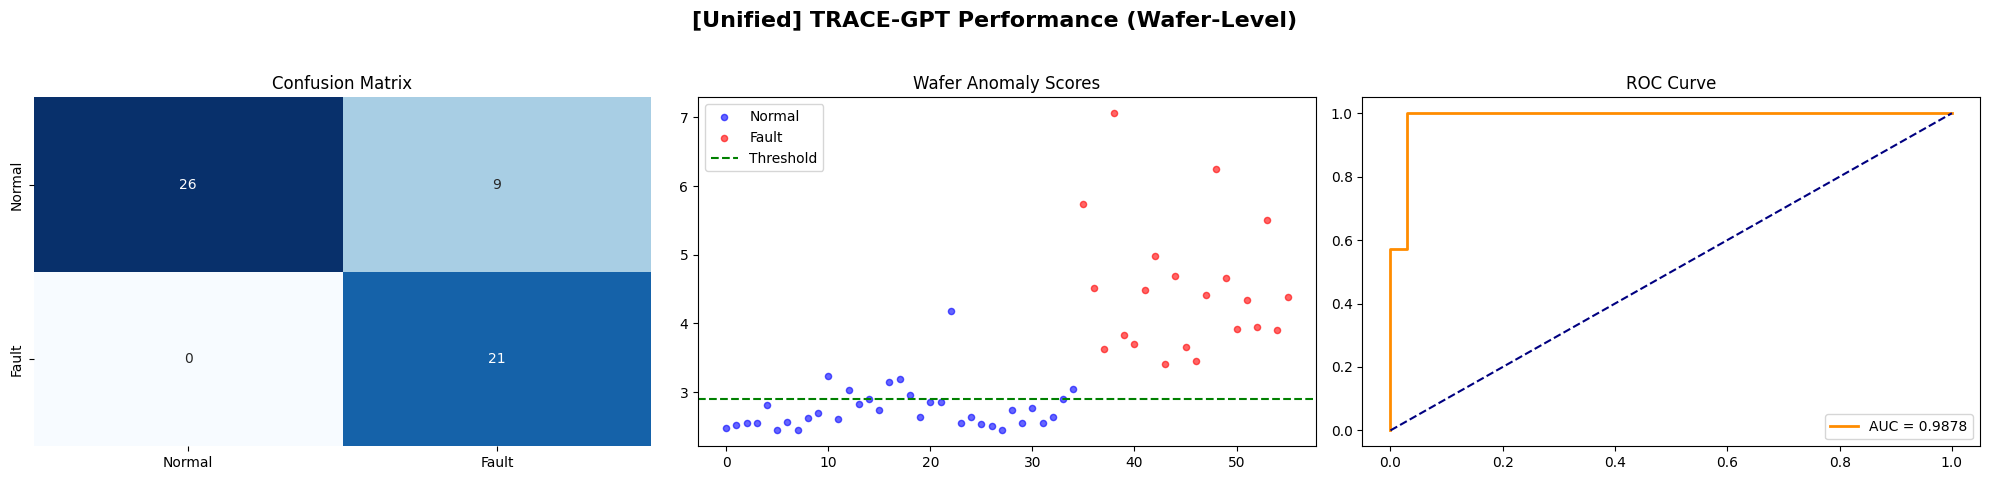

In [13]:
# ==========================================
# [Cell 3] 추론 및 평가 (Evaluation Phase)
# ==========================================
EXP_ID = 'Unified'
m_name = "TRACE-GPT"
BATCH_SIZE = 32

if m_name not in trained_artifacts or EXP_ID not in trained_artifacts[m_name]:
    print(f"❌ Error: Model '{m_name}' is not trained on '{EXP_ID}' yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on {EXP_ID} Dataset")

    # 1. 저장된 모델과 고유 변수 불러오기
    saved_model = trained_artifacts[m_name][EXP_ID]['model']
    fixed_threshold = trained_artifacts[m_name][EXP_ID]['threshold']
    config = trained_artifacts[m_name][EXP_ID]['config']

    # 2. Test Data 준비
    data = datasets[EXP_ID]
    test_norm = torch.FloatTensor(data['X_test_norm']).to(device)

    if len(data['X_test_fault']) > 0:
        test_fault = torch.FloatTensor(data['X_test_fault']).to(device)
    else:
        test_fault = torch.FloatTensor([]).to(device)

    ids_norm = data['ids_test_norm']
    ids_fault = data['ids_test_fault']

    # 3. 추론 수행 (Test Data 전용)
    print("Calculating Test Window Scores...")
    norm_window_scores = trace_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE, config["resolution"])

    if len(test_fault) > 0:
        fault_window_scores = trace_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE, config["resolution"])
    else:
        fault_window_scores = np.array([])

    # 4. Wafer 단위 집계
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    CALIBRATION_WINDOW = 10

    if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
        calibration_scores = norm_wafer_scores[:CALIBRATION_WINDOW]
        cal_mean = np.mean(calibration_scores)
        cal_std = np.std(calibration_scores)
        # 보정된 Test 데이터의 평균과 편차를 바탕으로 3-Sigma 적용
        calibrated_threshold = cal_mean + (3 * cal_std)
        print(f"\n📏 Calibrated Threshold (from first {CALIBRATION_WINDOW} Test Wafers): {calibrated_threshold:.6f}")
    else:
        calibrated_threshold = fixed_threshold # 데이터가 부족하면 기존 Train 임계값 사용
        print("\n⚠️ Not enough data for calibration. Using Train-based threshold.")
    # ==========================================

    # 5. 평가 및 시각화 (기존 fixed_threshold 대신 calibrated_threshold 사용)
    if len(np.unique(final_labels)) > 1:
        auc_score, f1 = evaluate_performance_fixed_threshold(
            m_name, EXP_ID, final_scores, final_labels, calibrated_threshold
        )

    # 결과 저장용 딕셔너리 업데이트
    if 'results' not in globals():
        results = {}
    results[EXP_ID] = {'AUC': auc_score, 'F1': f1}